**Setup**

In [2]:
import pandas as pd
import numpy as np
import mlflow
import shap
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import subprocess
import os
from dotenv import dotenv_values
from pathlib import Path

pd.set_option('display.max_columns', 200)
ROOT = Path().resolve().parent
config = dotenv_values(ROOT / ".env")

if not os.path.exists('../data/processed/final_data.parquet'):
    subprocess.run([
        'aws', 's3', 'cp',
        f's3://{config['S3_BUCKET_NAME']}/data/processed/final_data.parquet',
        '../data/processed/final_data.parquet',
        '--no-sign-request'
    ])

download: s3://materials-property-prediction-amul/data/processed/final_data.parquet to ../data/processed/final_data.parquet


**Load Data**

In [45]:
features_and_targets = pd.read_parquet('../data/processed/final_data.parquet')

**Set Up MLFlow Experiment Tracking**

In [46]:
mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("property_prediction")

<Experiment: artifact_location='mlflow-artifacts:/1', creation_time=1787607864524, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1787607864524, lifecycle_stage='active', name='property_prediction', tags={}, trace_location=None, workspace='default'>

**Pre-Processing + Training Loop**

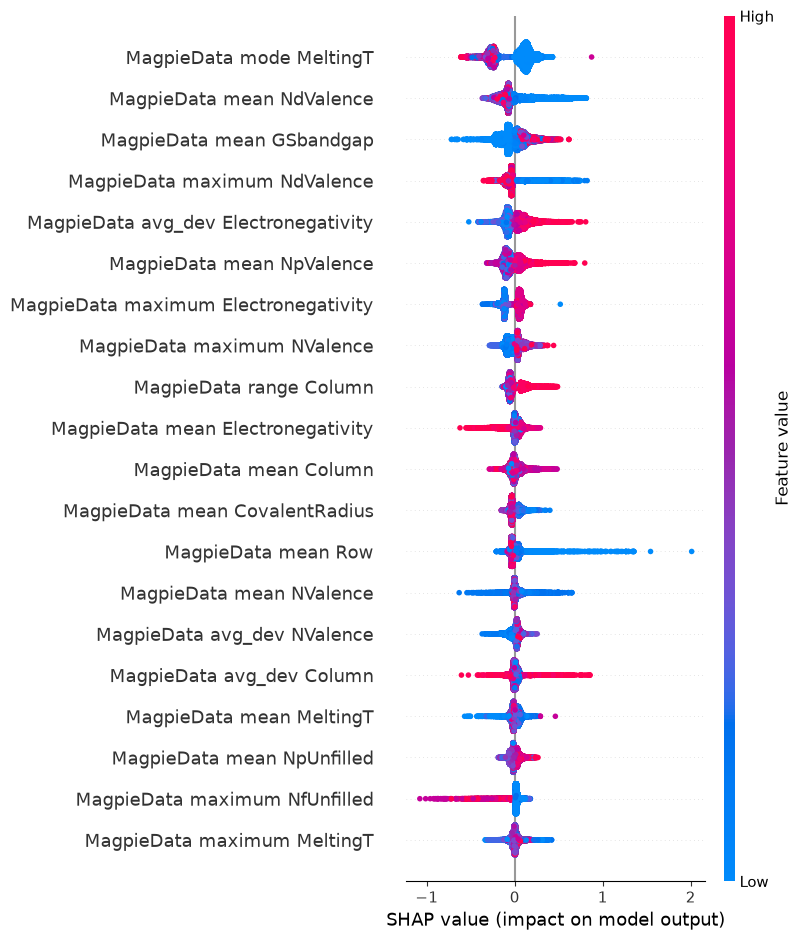

2026/08/27 23:23:18 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/27 23:23:20 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run band_gap at: http://127.0.0.1:5000/#/experiments/1/runs/54a8ed72669643ea99a76be644df3c21
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


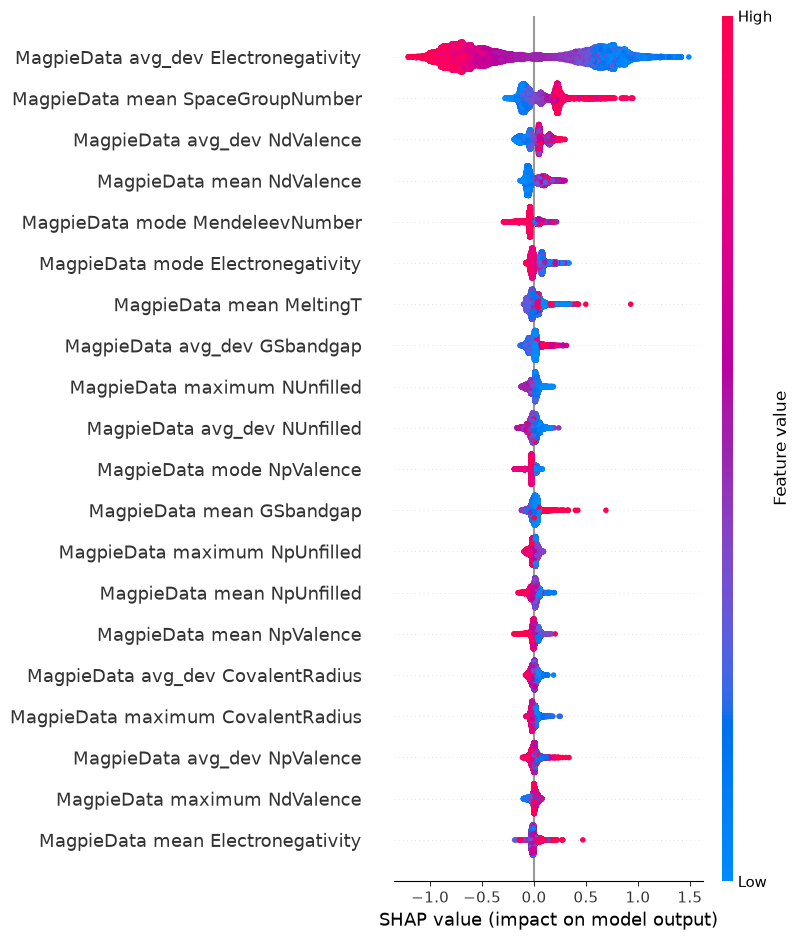

2026/08/27 23:23:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/27 23:23:36 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.
/Users/aprakash/general/materials_property_prediction/.venv/lib/python3.13/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


🏃 View run formation_energy_per_atom at: http://127.0.0.1:5000/#/experiments/1/runs/381a397392bb4616993772418b743c56
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


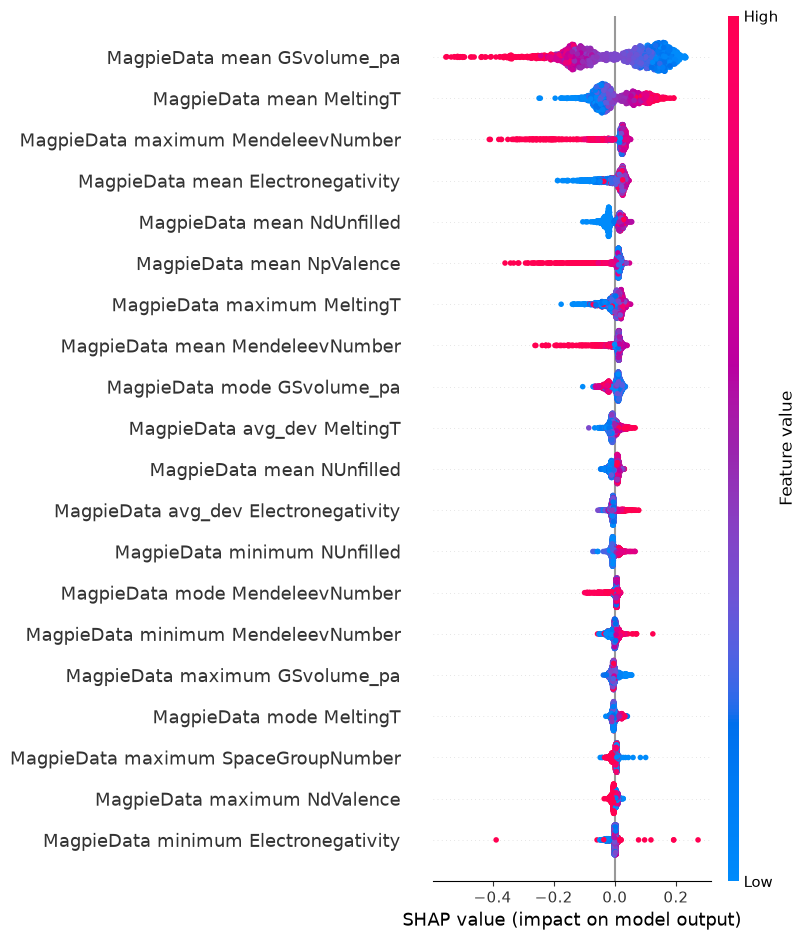

2026/08/27 23:23:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/08/27 23:23:40 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


🏃 View run bulk_modulus at: http://127.0.0.1:5000/#/experiments/1/runs/75118b6c00f04a36872a4213c26fd24e
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/1


In [60]:
properties = ['band_gap', 'formation_energy_per_atom', 'bulk_modulus']
for property in properties:
    df = features_and_targets.copy()
    # Filter df so target property value is not null
    df = df[df[property].notna()].reset_index(drop=True)
    if property=='bulk_modulus':
        df = df[df[property].between(0, 1000)].reset_index(drop=True)
        df[property] = np.log10(df[property])
        df = df[np.isfinite(df[property])].reset_index(drop=True)
    # Divide into feature and target dataframes
    features = df.iloc[:, 1: -3]
    targets = df[property]

    # 80/20 train/test split
    X_train, X_test, Y_train, Y_test = train_test_split(features, targets, test_size=0.2, random_state=42)

    # Scale Data
    scaler = StandardScaler()

    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    with mlflow.start_run(run_name = f"{property}"):
        model = XGBRegressor(n_estimators=1000, learning_rate=5e-2, max_depth=6, subsample=0.8, n_jobs=8)
        model.fit(X_train, Y_train)
        mlflow.log_params(model.get_params())

        pred = model.predict(X_test)
        rmse = np.sqrt(mean_squared_error(Y_test, pred))
        mae = mean_absolute_error(Y_test, pred)
        r2 = r2_score(Y_test, pred)
        mlflow.log_metric("rmse", rmse)
        mlflow.log_metric("mae", mae)
        mlflow.log_metric("r2", r2)
        explainer = shap.TreeExplainer(model)
        values = explainer.shap_values(X_test)
        shap.summary_plot(values, X_test, feature_names=features.columns, max_display=20)
        plt.close()
        fig, ax = plt.subplots(figsize=(6, 6))
        ax.scatter(Y_test, pred, alpha=0.3, s=5)
        ax.plot([Y_test.min(), Y_test.max()], [Y_test.min(), Y_test.max()], 'r--', linewidth=1)
        ax.set_xlabel(f"Actual {property}")
        ax.set_ylabel(f"Predicted {property}")
        ax.set_title(f"{property} — Predicted vs Actual")
        mlflow.log_figure(fig, f"pred_vs_actual_{property}.png")
        plt.close()

        mlflow.xgboost.log_model(model, f"{property}_xgboost_model")



**RESULTS**

In [69]:
runs = mlflow.search_runs(experiment_names=["property_prediction"])
maes = runs.set_index('tags.mlflow.runName')['metrics.mae']
maes = [maes[property] for property in properties]
maes = runs[['metrics.mae']].values.reshape(-1)
data = {
    "Property" : properties,
    "This MAE" : maes,
    "SOTA MAE" : [.0491, .0170, 0.1559],
    "Units" : ['log10 GPa', 'eV / atom', 'eV'],
    "SOTA Model" : ['coNGN', 'coGN', 'coGN']
}
results_df = pd.DataFrame(data)
results_df

,Property,This MAE,SOTA MAE,Units,SOTA Model
0,band_gap,0.080523,0.0491,log10 GPa,coNGN
1,formation_energy_per_atom,0.174888,0.0170,eV / atom,coGN
2,bulk_modulus,0.473340,0.1559,eV,coGN
